In [1]:
import pandas as pd
import numpy as np
import math 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_rows",None)
pd.set_option("display.max_columns",None)

In [3]:
df=pd.read_csv("D:\\skill improvement\\churn data\\data\\Churn_Modelling.csv")

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.shape

(10000, 14)

In [6]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

there is no null value in any data 

In [7]:
# checking for duplicate values in the data 
df.duplicated().sum()

np.int64(0)

NO DUPLICATED VALUES IN THE DATA

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


# investigate later
1. [] check does feamle are less likly in acitvemember
2. [] does geograohy female and exited have any realtion
3. # lets check if the number of product have any realtion with with tenure .do new customer have only enter for the product use.?
df.groupby(df[(df['tenure_class']=='new') &(df['NumOfProducts']>=3)]['NumOfProducts'])['Exited'].mean()*100

## exited

In [9]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

<Axes: xlabel='Exited'>

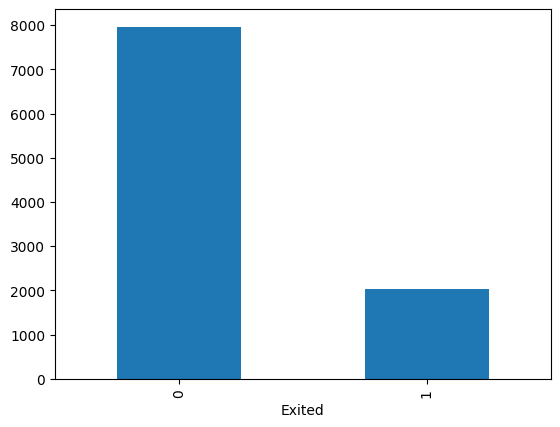

In [10]:
df["Exited"].value_counts().plot(kind='bar')

Exited:
exited have 0 as 7963 AND 1 as 2037 indicating an uneven dataset ,unbalanced data set .with majorty of the customer who havenot churned the data and vfew with the churn rate 

checking if any customer id is been reped for not



In [11]:
df['CustomerId'].value_counts(sort='desencding')

CustomerId
15656710    1
15768163    1
15672754    1
15719276    1
15692664    1
15703563    1
15579969    1
15656062    1
15666295    1
15695474    1
15806455    1
15747927    1
15721377    1
15587133    1
15806360    1
15733491    1
15706552    1
15589475    1
15656300    1
15728693    1
15700772    1
15736816    1
15738191    1
15625047    1
15725737    1
15699309    1
15597945    1
15577657    1
15568982    1
15661507    1
15788218    1
15737452    1
15771573    1
15602280    1
15754849    1
15684171    1
15755196    1
15687946    1
15738148    1
15619360    1
15585768    1
15717426    1
15729599    1
15788448    1
15794171    1
15732963    1
15659428    1
15750181    1
15751208    1
15702014    1
15773469    1
15651280    1
15804771    1
15623944    1
15647091    1
15630053    1
15760861    1
15569590    1
15702298    1
15683553    1
15768193    1
15616550    1
15771873    1
15766205    1
15803136    1
15575185    1
15662085    1
15614049    1
15780961    1
15770811    1
15779052 

there is no elemnet with same customer id

In [12]:
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
2462,2463,15704442,Fleming,672,France,Female,53,9,169406.33,4,1,1,147311.47,1
5322,5323,15699830,Doherty,721,France,Female,40,7,0.00,2,1,1,122580.48,0
7474,7475,15799859,Lucchesi,704,France,Male,50,4,165438.26,1,1,0,120770.75,1
1918,1919,15744105,Kodilinyechukwu,768,France,Female,28,3,109118.05,2,0,1,50911.41,0
4958,4959,15594502,Zotov,655,France,Male,37,6,109093.41,2,1,0,1775.52,0


# surname

In [13]:
# // checking for the surname to see if they are from a specif are or a perticular family
df['Surname'].value_counts()

Surname
Smith                      32
Scott                      29
Martin                     29
Walker                     28
Brown                      26
Genovese                   25
Yeh                        25
Shih                       25
Wright                     24
Maclean                    24
Ma                         23
Wilson                     23
Fanucci                    23
White                      23
Lu                         22
Wang                       22
Moore                      22
Chu                        22
Johnson                    22
Mai                        21
Sun                        21
Thompson                   21
McGregor                   21
Hughes                     20
Palerma                    20
Kennedy                    20
Kerr                       20
Jamieson                   20
Lo                         20
Graham                     20
Trevisani                  20
Fang                       20
Kao                        20
Mi

<Axes: xlabel='Surname'>

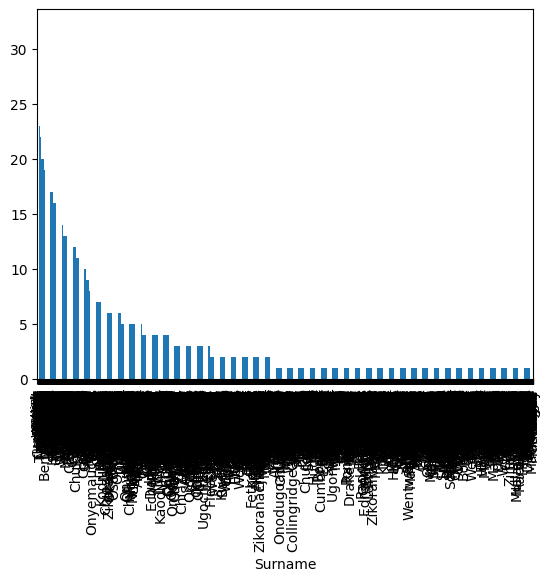

In [14]:
df['Surname'].value_counts().plot(kind='bar')

# CreditScore

In [15]:
# cheking for the credict score is there any perticular error or and data errror in the data 
df['CreditScore'].describe()

count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64

<Axes: xlabel='CreditScore', ylabel='Count'>

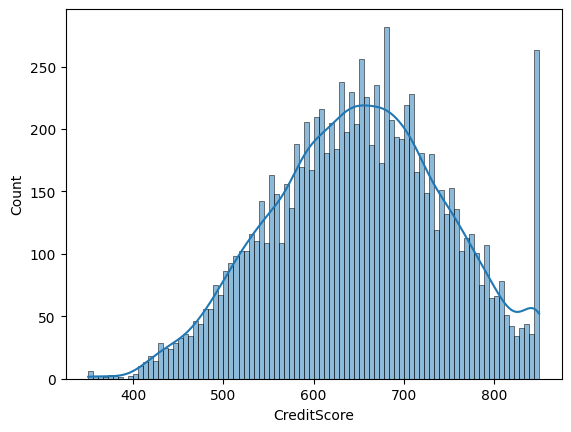

In [16]:
sns.histplot(data=df,x=df['CreditScore'],kde=True,bins=90)

In [17]:

(df['CreditScore']==850).sum()

np.int64(233)

<Axes: ylabel='CreditScore'>

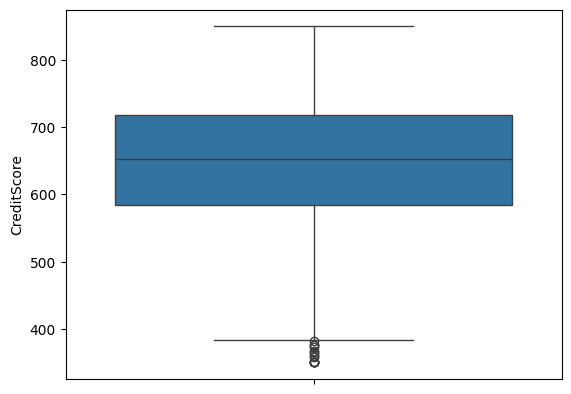

In [18]:
sns.boxplot(df['CreditScore'])

In [19]:
q1=df['CreditScore'].quantile(0.25)
q3=df['CreditScore'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
outliers = df[df['CreditScore'] < lower_bound]
print("the number of values in lower_bound= ",len(outliers))
print("cutoff = ",lower_bound)
outliers

the number of values in lower_bound=  15
cutoff =  383.0


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
942,943,15804586,Lin,376,France,Female,46,6,0.00,1,1,0,157333.69,1
1193,1194,15779947,Thomas,363,Spain,Female,28,6,146098.43,3,1,0,100615.14,1
1405,1406,15612494,Panicucci,359,France,Female,44,6,128747.69,1,1,0,146955.71,1
1631,1632,15685372,Azubuike,350,Spain,Male,54,1,152677.48,1,1,1,191973.49,1
1838,1839,15758813,Campbell,350,Germany,Male,39,0,109733.20,2,0,0,123602.11,1
1962,1963,15692416,Aikenhead,358,Spain,Female,52,8,143542.36,3,1,0,141959.11,1
2473,2474,15679249,Chou,351,Germany,Female,57,4,163146.46,1,1,0,169621.69,1
2579,2580,15597896,Ozoemena,365,Germany,Male,30,0,127760.07,1,1,0,81537.85,1
8154,8155,15791533,Ch'ien,367,Spain,Male,42,6,93608.28,1,1,0,168816.73,1


creditscore:
1. the creditscore is btween 350 to 850 .with the mean of 650 .the 25% of the customer have creditscore less than 584. as the mean and meadian is roughtlysame it indicate  semitic dstribution of the data .as  the std is 96 it show a rought normaldistribution of the data
2. there is spik in the cutomer with the credit score 850 .is roughly 233 customer .
3. as looking at the boxplot for the creditscore it show there are some customer outside the lower whisker .indicating these could be possible outliers in the data.the data outlier all have churn rate 100 indicating a pattern between credit score and exited customers
4. we need to check wthe the credit score have any affect on the churn data .


# geography


In [20]:
#  checking the data is from which contryes 
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

<Axes: xlabel='Geography'>

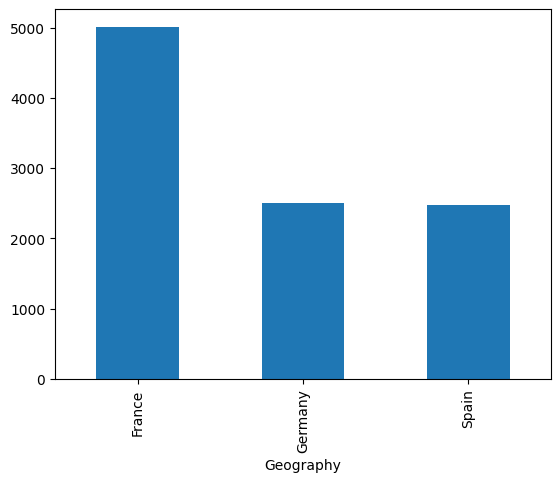

In [21]:
df['Geography'].value_counts().plot(kind='bar')

# gender

In [22]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

<Axes: xlabel='Gender', ylabel='count'>

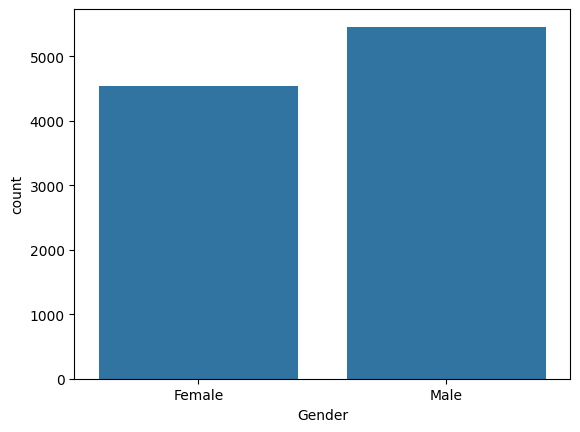

In [23]:
sns.countplot(x=df['Gender'])

1. the gender have twoo class with male and female with the male(5457) and female with (4543). this is rougly balance so we dont need any more proccess on this data
2. we need to check wther there is any relation with churn data 

# age

In [24]:
# checking for the age of the customer to classify the data into different age groups and to see if there is any outliers in the data
df['Age'].describe()

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64

<Axes: xlabel='Age', ylabel='Count'>

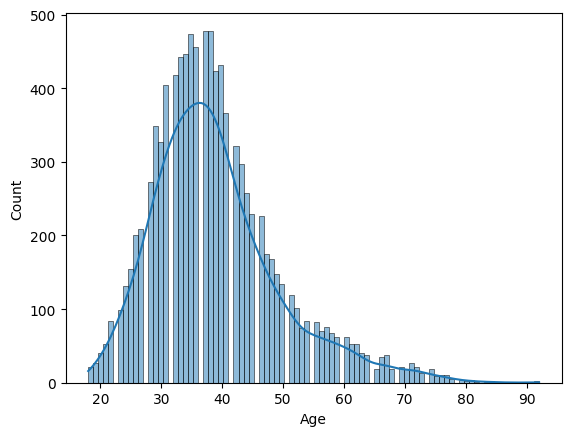

In [25]:
sns.histplot(data=df,x=df['Age'],kde=True,bins=90)

In [26]:
# does the age have any impact of the churn people or  not 
df['AgeGroup'] = pd.cut(df['Age'], 
                          bins=[18,39,64, 100], 
                          labels=['young', 'middle adulthoob',"senior"])

df['AgeGroup'].value_counts()

AgeGroup
young               5965
middle adulthoob    3731
senior               282
Name: count, dtype: int64

<Axes: xlabel='AgeGroup', ylabel='count'>

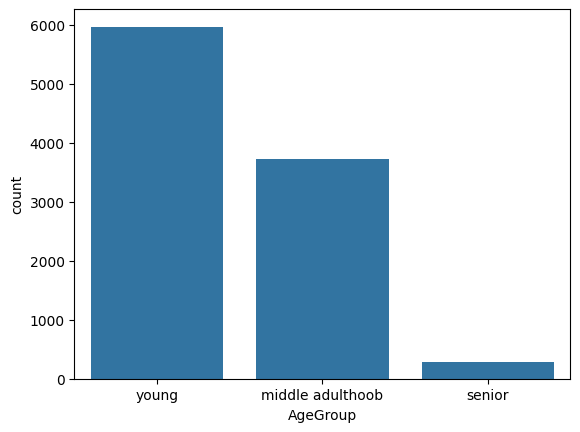

In [27]:
sns.countplot(data=df, x='AgeGroup')


1. the age group have a range of 18 to 92 were std 10 and the mean is 38 were as meadian is 37 indicating a roughly  normal distribution of the data 
2. have divide the age column into 3 class were the young(18-39),adult(40-65),and senior is 66+
3. to check the type of customer who use are product
4. there are more young customer with 5065 in the data follwed up by adult qith 3731 and 282 senior customer 
5. we have to check the relation btween the age and exited customer .to see if any specific class is to churn more 
 

In [29]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup
2168,2169,15805260,Wood,705,Germany,Female,56,2,143249.67,1,1,0,88428.41,1,middle adulthoob
6341,6342,15658364,Laney,807,Germany,Female,40,1,134590.21,1,1,1,46253.65,0,middle adulthoob
6507,6508,15764253,Ramsey,742,France,Male,32,6,160485.16,1,1,0,29023.03,0,young
4664,4665,15580719,Davis,697,France,Female,23,10,0.00,2,1,1,79734.23,0,young


# tenure


In [30]:
# tenure :what is the max and minum year a customer have been with us
df['Tenure'].describe()

count    10000.000000
mean         5.012800
std          2.892174
min          0.000000
25%          3.000000
50%          5.000000
75%          7.000000
max         10.000000
Name: Tenure, dtype: float64

In [31]:
df['Tenure'].value_counts()

Tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64

<Axes: xlabel='Tenure'>

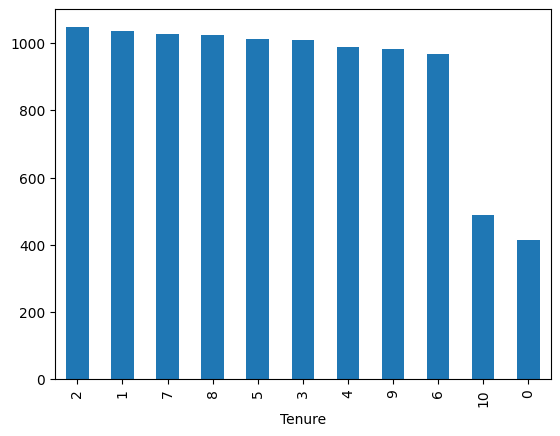

In [32]:
df['Tenure'].value_counts().plot(kind='bar')

# observation:
0. the tenure is range between 0 to 10.with most of the customer with 1 to 2 and else rest there are  few customer who have zero tenure and 10 year.
1. we can break the group into bins with new,middle ans loyal customer to check relation of them with churn data.


# balance

In [33]:
df['Balance'].describe()

count     10000.000000
mean      76485.889288
std       62397.405202
min           0.000000
25%           0.000000
50%       97198.540000
75%      127644.240000
max      250898.090000
Name: Balance, dtype: float64

<Axes: xlabel='Balance', ylabel='Count'>

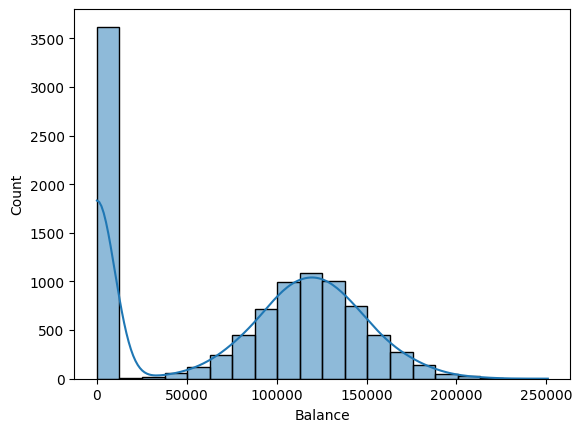

In [34]:
sns.histplot(df['Balance'],kde=True,bins=20)

In [35]:
#  checking the numebr of customer with 0 balance
(df['Balance']==0).sum()

np.int64(3617)

<Axes: ylabel='Balance'>

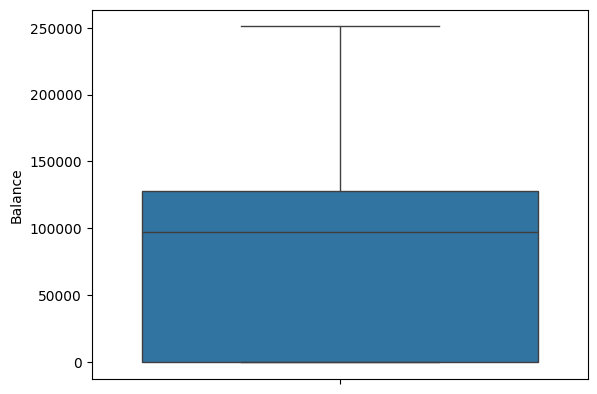

In [36]:
sns.boxplot(df['Balance'])

In [37]:
# cheking the iqr range of the data :
q1=df['Balance'].quantile(0.25)
q3=df['Balance'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
outliers=df[df['Balance']<lower_bound]
print(f"the lower round range is {lower_bound} and upper bound is {upper_bound}")
print(f"number of outliers are {len(outliers)}")

the lower round range is -191466.36000000002 and upper bound is 319110.60000000003
number of outliers are 0


observation :
1. customer balance ranges from 0 to 250k ,with a mean of 70k and the std to be 62397and the median of 97198 .the alignment betwween the mean and meadian is not same indicating the rought asymetric distributuion of the data.
2. the 25% of the customer have 0 balnce and the rest have from 97198 to250k. indicating a hidden patern btween these too.we need to check what are the customer with zero balznce are they new customer or any other possible cause.
3. this pattern arrise a question wther the customer with zero balnce have diifrent churn rate then the active customer with balnce 

In [39]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup
3184,3185,15631070,Gerasimova,667,Germany,Male,55,9,154393.43,1,1,1,137674.96,1,middle adulthoob
4010,4011,15685654,Allan,514,Spain,Male,66,9,0.00,2,1,1,14234.31,0,senior
5570,5571,15645847,P'eng,569,Germany,Male,35,2,109196.66,3,1,0,109393.19,1,young
6905,6906,15754012,Shepherdson,687,France,Female,35,1,110752.15,2,1,1,47921.22,0,young


# number of product

In [40]:
df['NumOfProducts'].value_counts()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

<Axes: xlabel='NumOfProducts', ylabel='count'>

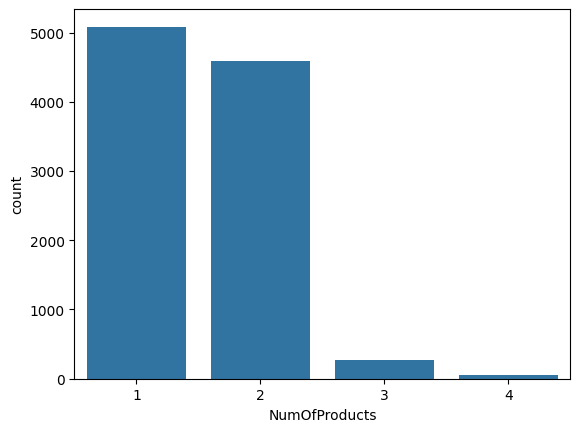

In [41]:
sns.countplot(x=df['NumOfProducts'])

numofproduct:
1. the range of the product varies from 1 to 4 with the most customer with 1 product and least with 4 products
2. the numofprocut can be a cause for the  churn customer .



In [44]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup
7916,7917,15610936,Becher,562,France,Male,33,6,0.00,2,1,0,111590.35,0,young
9371,9372,15781987,Akhtar,641,France,Male,31,9,112494.99,1,1,1,32231.60,0,young
2730,2731,15730339,Bell,670,Spain,Male,30,3,133446.34,1,0,0,3154.95,0,young
9571,9572,15716085,Norris,739,Spain,Female,41,8,0.00,1,1,0,191694.77,1,middle adulthoob


# has credit card

In [45]:
# has credict card
df['HasCrCard'].value_counts()

HasCrCard
1    7055
0    2945
Name: count, dtype: int64

<Axes: xlabel='HasCrCard', ylabel='count'>

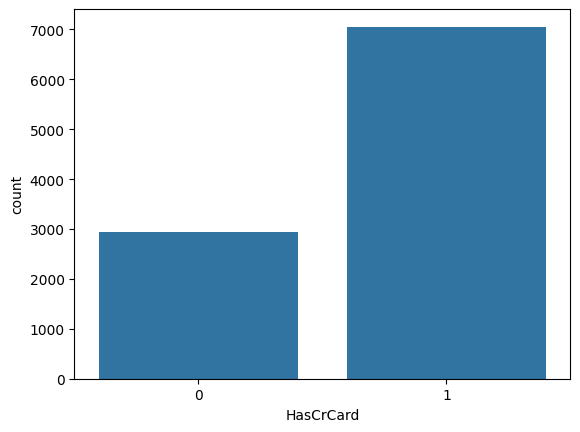

In [46]:
sns.countplot(x=df['HasCrCard'])

hascrcard
1. umbalnaced dataset with no crcard customers

In [49]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup
4576,4577,15770984,Fanucci,697,Spain,Female,40,7,130334.35,2,0,1,116951.10,0,middle adulthoob
9052,9053,15597949,Gilbert,768,Germany,Female,47,5,104552.61,1,1,0,48137.08,1,middle adulthoob
1821,1822,15621432,Lee,630,Spain,Male,35,1,0.00,2,0,0,186826.22,0,young
1692,1693,15809006,Walker,602,France,Male,23,7,113758.48,2,0,0,84077.60,0,young


# isactivemember

In [50]:
df['IsActiveMember'].value_counts()

IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

<Axes: xlabel='IsActiveMember'>

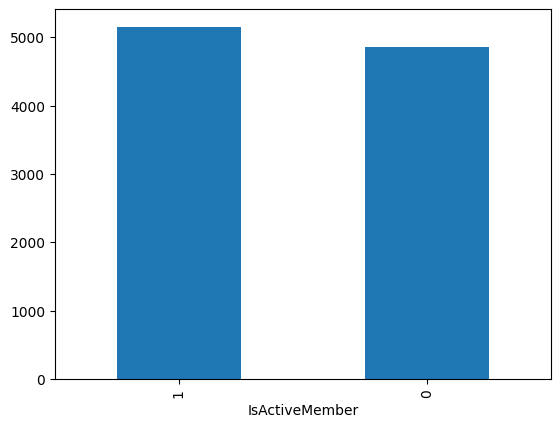

In [51]:
df['IsActiveMember'].value_counts().plot(kind='bar')

# estimated sallary

In [53]:
# estimate salary
df['EstimatedSalary'].describe()

count     10000.000000
mean     100090.239881
std       57510.492818
min          11.580000
25%       51002.110000
50%      100193.915000
75%      149388.247500
max      199992.480000
Name: EstimatedSalary, dtype: float64

In [54]:
df['EstimatedSalary'].shape

(10000,)

In [55]:
df['EstimatedSalary'].nunique()

9999

<Axes: xlabel='EstimatedSalary', ylabel='Count'>

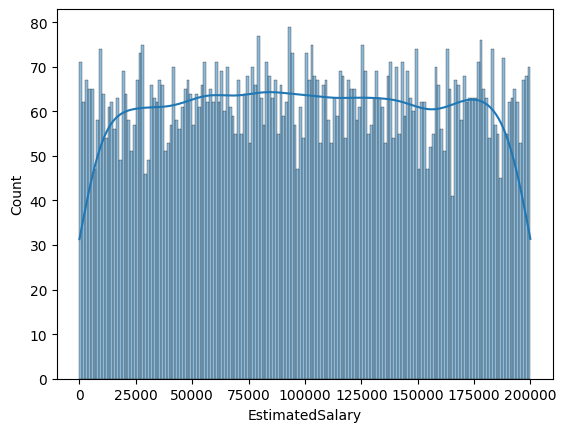

In [56]:
sns.histplot(df['EstimatedSalary'],kde=True,bins=160)

observation:
The EstimatedSalary feature appears to follow an approximately uniform distribution across its range (0–200,000). There are no significant peaks, skewness, or clusters, indicating that customers are evenly distributed across different salary levels. This suggests that the dataset was likely generated or sampled to cover the full salary range rather than reflecting a naturally occurring salary distribution.

Estimatedsalary
1. estimate salary ranges from 11 to 1999992 , the mean is 100090 and the meadian is about the same with 100193 .indicating a roughly simeritric data formation 
there are 25% of the people with salary about 50k 
the min salry of the persom is 11.58 could be a point to discuss 

In [57]:
df[df['EstimatedSalary']<100]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup
2362,2363,15791053,Lucciano,709,Germany,Male,45,4,122917.71,1,1,1,11.58,1,middle adulthoob
5548,5549,15639662,Phillips,710,France,Male,38,2,0.00,2,1,0,96.27,0,young
9010,9011,15786463,Hsing,645,Germany,Female,59,8,121669.93,2,0,0,91.75,1,middle adulthoob
9647,9648,15679693,Walker,625,France,Male,31,5,0.00,2,0,1,90.07,0,young


# Bivarent eda

In [58]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup
4423,4424,15739857,Trentino,785,France,Female,40,3,0.00,2,1,1,96832.82,0,middle adulthoob
307,308,15660211,Shih,629,Germany,Male,35,7,156847.29,2,1,0,31824.29,0,young
106,107,15599195,Stiger,582,Germany,Male,32,1,88938.62,1,1,1,10054.53,0,young
6509,6510,15730590,Ko,738,Germany,Female,40,1,115409.18,2,0,0,180456.80,0,middle adulthoob


# credit score vs exited


In [59]:
# lets create a new feature with 3 class for credit score[poor,good,excellent]
df['credit_score_class'] = pd.cut(df['CreditScore'],
                                  bins=[300,549,649,749,900],
                                  labels=['Poor','fair','good','excellent'])
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,credit_score_class
8762,8763,15765173,Lin,350,France,Female,60,3,0.00,1,0,0,113796.15,1,middle adulthoob,Poor
5582,5583,15596972,Brownlow,534,France,Male,38,3,0.00,1,0,0,143938.27,0,young,Poor
3262,3263,15654456,Napolitano,511,Germany,Male,48,6,149726.08,1,0,0,88307.87,1,middle adulthoob,Poor
1973,1974,15635728,P'an,693,France,Male,41,4,0.00,2,0,0,156381.47,0,middle adulthoob,good


In [60]:
df['credit_score_class'].value_counts()

credit_score_class
good         3477
fair         3310
excellent    1623
Poor         1590
Name: count, dtype: int64

In [61]:
# now as we have divided the creditscore column into other sub class we need to check the relation between the churn rate and the credit score class
df.groupby(df['credit_score_class'])['Exited'].mean()*100 


C:\Users\karan\AppData\Local\Temp\ipykernel_20744\3562721763.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df['credit_score_class'])['Exited'].mean()*100


credit_score_class
Poor         22.704403
fair         20.785498
good         19.183204
excellent    19.778189
Name: Exited, dtype: float64

In [62]:
# now as we have divided the creditscore column into other sub class we need to check the relation between the churn rate and the credit score class
df.groupby(df['credit_score_class'])['Exited'].value_counts()


C:\Users\karan\AppData\Local\Temp\ipykernel_20744\2037143163.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df['credit_score_class'])['Exited'].value_counts()


credit_score_class  Exited
Poor                0         1229
                    1          361
fair                0         2622
                    1          688
good                0         2810
                    1          667
excellent           0         1302
                    1          321
Name: count, dtype: int64

observation :
1. i have divided the credict score into 4 sub class poor,fair,good,execlent to see what size group have impact on the churn rate
2. the poor[1590][22] fair[3310][20]good [1602][19]excelent[1523][19] were as the churn rate .as there is not much of the change in the data/churn rate it indicated as poor reltaion with the churn data .
3. we need to check wther the credit score have any sort of relation with any other kind
 

In [63]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,credit_score_class
8988,8989,15812279,William,634,France,Male,37,5,115345.86,2,0,0,168781.80,0,young,fair
4208,4209,15628558,Pan,447,France,Female,44,5,89188.83,1,1,1,75408.24,0,middle adulthoob,Poor
1612,1613,15649121,Pinto,665,France,Male,52,3,0.00,1,1,0,116137.01,1,middle adulthoob,good
7140,7141,15716082,Chukwubuikem,703,Spain,Male,39,6,152685.40,1,0,0,183656.12,0,young,good


# geography vs exited

In [64]:
# checking if churn rate have anything to do with geography area
(df.groupby(df['Geography'])['Exited'].mean()*100).sort_values(ascending=False)


Geography
Germany    32.443204
Spain      16.673395
France     16.154767
Name: Exited, dtype: float64

In [65]:
df.groupby(df['Geography'])['Exited'].value_counts()

Geography  Exited
France     0         4204
           1          810
Germany    0         1695
           1          814
Spain      0         2064
           1          413
Name: count, dtype: int64


1. the geography contains 3 value,france,germany,spain,. the france is the counry with most custoomers from follwed up by germany and then spain.
the churn rate percentage of the france is 16 .and the germany is 32 percent.half of the customer of germony have churned .indicating a sepcific relation between geography and churn customer. why does germany customer churn so much could be a point to research .

In [66]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,credit_score_class
1322,1323,15598846,Shahan,700,France,Female,44,2,58781.76,1,1,0,16874.92,0,middle adulthoob,good
8312,8313,15609977,Mundy,587,France,Male,47,6,71026.77,1,1,0,57962.41,0,middle adulthoob,fair
7405,7406,15704315,Teng,556,France,Male,34,8,163757.06,1,1,1,104000.06,0,young,fair
9768,9769,15644994,Ko,714,Germany,Male,54,4,137986.58,2,0,1,51308.54,1,middle adulthoob,good


# gender vs exited

In [67]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [68]:
df.groupby(df['Gender'])['Exited'].mean()*100


Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64

In [69]:
df.groupby(df['Gender'])['Exited'].value_counts()


Gender  Exited
Female  0         3404
        1         1139
Male    0         4559
        1          898
Name: count, dtype: int64

observation:
1. the gender[m,f] column have some relation with the churn rate as there are more female(25%) to churn rather than the male(16) .indicating some sort of relation with the churn rate . we futher need to check wther there is any realtion with any other column which can cause this problem.
2. lets check wther the quantaty of female have any sepecific location(geography) 

# gender vs geography

In [70]:
df.groupby(df['Geography'])['Gender'].value_counts()

Geography  Gender
France     Male      2753
           Female    2261
Germany    Male      1316
           Female    1193
Spain      Male      1388
           Female    1089
Name: count, dtype: int64

observation:
1. there is not any kind of specific info avalabel for the gender and geography columns . indicating a very few relation btween these twoo

# gender vs isactivemember


In [71]:
df.groupby(['Gender'])['IsActiveMember'].value_counts()

Gender  IsActiveMember
Female  1                 2284
        0                 2259
Male    1                 2867
        0                 2590
Name: count, dtype: int64

observation:
1. there realtion bewttern gender and isactivemember is rougly same .same number of acitve nad inactive member present .assuming a very low reltino btweeen these too but we can check the relation with exitced to see any other diffrence 

In [72]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,credit_score_class
7232,7233,15799785,Ikemefuna,679,Germany,Female,30,4,77949.69,1,1,1,121151.46,0,young,good
6581,6582,15598744,Ch'ang,576,Germany,Female,71,6,140273.47,1,1,1,193135.25,1,senior,fair
947,948,15741336,Ejimofor,715,France,Female,38,5,118590.41,1,1,1,5684.17,1,young,good
5455,5456,15726855,Oliver,805,Germany,Female,45,9,116585.97,1,1,0,189428.75,1,middle adulthoob,excellent


# gendre vs agegroup

In [73]:
df.groupby(["Gender"])["AgeGroup"].value_counts()

Gender  AgeGroup        
Female  young               2630
        middle adulthoob    1781
        senior               128
Male    young               3335
        middle adulthoob    1950
        senior               154
Name: count, dtype: int64

observation:
1. there is not specific relation or point to note inthe gender vs agegroup.indcatinf a samll reltion btween them 

# agegroup vs exited 

In [74]:
(df.groupby(df['AgeGroup'])['Exited'].mean()*100).sort_values(ascending=False)



C:\Users\karan\AppData\Local\Temp\ipykernel_20744\23430265.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (df.groupby(df['AgeGroup'])['Exited'].mean()*100).sort_values(ascending=False)


AgeGroup
middle adulthoob    37.443045
senior              15.248227
young                9.974853
Name: Exited, dtype: float64

In [75]:
df.groupby(df['AgeGroup'])['Exited'].value_counts()

C:\Users\karan\AppData\Local\Temp\ipykernel_20744\795153283.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(df['AgeGroup'])['Exited'].value_counts()


AgeGroup          Exited
young             0         5370
                  1          595
middle adulthoob  0         2334
                  1         1397
senior            0          239
                  1           43
Name: count, dtype: int64

observation:
1. i have divide the age chart into 3 part[young,adult,senior].there for the we have young customer with the customer 595 churned (out of 5965 ) and adult churned with 1397(out of 3717 ) making 37 % churn rate and we have very few senior customer with churn rate of 15 % (total count us 282 ).
2. there are very few customer who have churned from young age . wereas the customer who adut have a very huge churn rate.the customer churned form adult is roughly double the size of young people.rather the adultis having roughly half of the cusotmer in the age group.this could cause us a risk.but it is yet to serch why is this churning so much
3. we need to futher see why are the adut group churning so much .is it beacuse of the geography or any kind of product or balnce issue .we need to run a reserch on these
4. The senior group is small (n=282) with a 15.2% churn rate — lower than middle adulthood but based on a much smaller sample than the other two groups, so this rate should be treated as less statistically reliable and not over-interpreted as a strong "seniors are loyal" finding.

In [76]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,credit_score_class
6254,6255,15721047,Ansell,578,Germany,Male,37,1,135650.88,1,1,0,199428.19,0,young,fair
2397,2398,15747724,Briggs,671,Spain,Female,34,10,0.00,1,1,0,23235.38,0,young,good
1516,1517,15701333,Blackburn,646,France,Female,37,7,96558.66,1,0,0,163427.18,0,young,fair
3018,3019,15811613,Voss,588,France,Female,27,8,0.00,1,1,0,20066.38,0,young,fair


# tenure vs exited

In [77]:
(df.groupby(['Tenure'])['Exited'].mean()*100).sort_values(ascending=False)

Tenure
0     23.002421
1     22.415459
9     21.646341
3     21.110010
5     20.652174
10    20.612245
4     20.525784
6     20.268873
8     19.219512
2     19.179389
7     17.217899
Name: Exited, dtype: float64

In [78]:
(df.groupby(['Tenure'])['Exited'].value_counts())

Tenure  Exited
0       0         318
        1          95
1       0         803
        1         232
2       0         847
        1         201
3       0         796
        1         213
4       0         786
        1         203
5       0         803
        1         209
6       0         771
        1         196
7       0         851
        1         177
8       0         828
        1         197
9       0         771
        1         213
10      0         389
        1         101
Name: count, dtype: int64

observation:
the tenure and exited does seem to have that much effect on the churn rate there is very slighlty dependence of the tenure over the exited group.
we can group the tenure into some sub classed to see if they show some relation with the churn /exited label.


In [79]:
#  we are going to divide the tenure column into three sub classed with [new,average, loyal ] customer to check of there is any chang in the relation ship
df['tenure_class']=pd.cut(df['Tenure'],
                          bins=[-1,2,5,10],
                          labels=['new','mid','loyal'])

In [80]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,credit_score_class,tenure_class
3393,3394,15600626,Bradley,710,France,Male,30,6,0.00,2,1,1,8991.17,0,young,good,loyal
8715,8716,15750837,Landseer,579,Germany,Male,41,0,141749.68,1,0,1,9201.53,0,middle adulthoob,fair,new
8523,8524,15567778,Genovese,690,Germany,Female,54,1,144027.80,1,1,1,108731.02,1,middle adulthoob,good,new
9325,9326,15786389,Chuang,635,Spain,Female,41,10,0.00,2,1,1,61994.20,0,middle adulthoob,fair,loyal


# tenure_class vs exited

In [81]:
df.groupby(['tenure_class'])['Exited'].mean()*100

C:\Users\karan\AppData\Local\Temp\ipykernel_20744\1947653593.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['tenure_class'])['Exited'].mean()*100


tenure_class
new      21.153846
mid      20.764120
loyal    19.670672
Name: Exited, dtype: float64

In [82]:
df.groupby(['tenure_class'])['Exited'].value_counts()

C:\Users\karan\AppData\Local\Temp\ipykernel_20744\3693644910.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['tenure_class'])['Exited'].value_counts()


tenure_class  Exited
new           0         1968
              1          528
mid           0         2385
              1          625
loyal         0         3610
              1          884
Name: count, dtype: int64

observation:
1. the new[21%] were mid[20] and loyal[19] churn rate .
2. the bivarent eda of tenure_class and exited doesnt show much of the relation. there is slighty diffrence when we gow from new to loyal customer the churn rate decrese .


In [83]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,credit_score_class,tenure_class
2074,2075,15805303,Olisanugo,661,Germany,Male,44,1,141136.62,1,1,0,189742.78,1,middle adulthoob,good,new
4000,4001,15600692,West,520,France,Male,38,5,0.00,2,1,0,163185.76,0,young,Poor,mid
3672,3673,15706904,Robertson,750,France,Male,43,6,113882.31,1,1,1,74564.41,0,middle adulthoob,excellent,loyal
7685,7686,15769980,Singleton,705,Germany,Female,40,3,92889.91,1,1,1,109496.69,0,middle adulthoob,good,mid


In [84]:
df['tenure_class'].value_counts()

tenure_class
loyal    4494
mid      3010
new      2496
Name: count, dtype: int64

# balance vs exited 

In [94]:
#  checking if the customer with zero balance have high churn rate than the balnce customer 
zero_balnce=(df['Balance']==0).mean()*100 # checking for the percentage of people with zero balace
print(f"% of the customer have zero balnce = {round(zero_balnce)} %")
# checking if the balnce zero ahve relation with churn cutomer,
print(df.groupby(df["Balance"] == 0)["Exited"].mean() * 100)


% of the customer have zero balnce = 36 %
Balance
False    24.079586
True     13.823611
Name: Exited, dtype: float64


observation :
1. zero vs balance 
Contrary to the assumption that zero-balance customers are more likely to be disengaged and churn, the data shows the opposite: customers with a non-zero balance churn at 24.1%, nearly double the 13.8% churn rate of zero-balance customers (who make up 36% of the customer base). This suggests zero-balance customers may primarily hold non-deposit products (e.g., credit cards or loans) where balance isn't a meaningful engagement signal, while customers with real balances may be more likely to actively compare and switch to competitor offers. This reframes Balance from a simple "more balance = more engaged" assumption into a feature that likely interacts with NumOfProducts and needs closer segmentation rather than being treated as a standalone predictor.

In [95]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,credit_score_class,tenure_class
1864,1865,15805312,Bellucci,607,France,Male,45,7,123859.60,1,0,1,113051.57,0,middle adulthoob,fair,loyal
7739,7740,15689952,Zuyeva,724,Spain,Male,41,5,0.00,1,0,1,115753.94,0,middle adulthoob,good,mid
6514,6515,15625141,Porter,563,Spain,Male,26,7,0.00,2,0,0,6139.74,0,young,fair,loyal
9149,9150,15814331,Lung,597,Germany,Female,43,7,119127.46,2,1,0,55809.92,0,middle adulthoob,fair,loyal


# number of product vs exited

In [96]:
df.groupby(df['NumOfProducts'])['Exited'].mean()*100



NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64

In [97]:
df.groupby(df['NumOfProducts'])['Exited'].value_counts()

NumOfProducts  Exited
1              0         3675
               1         1409
2              0         4242
               1          348
3              1          220
               0           46
4              1           60
Name: count, dtype: int64

noofproduct vs exited
1. the most number of people have churned form the 1 with the count of 1409
2. there are very few customer who have churend from 2 .indicating customer with 2 product are more likely loyal to the bank
3. there is huge churn rate btween 3 and 4 almost all of the customer have churned from the bank.indicating some issue with this

In [98]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,credit_score_class,tenure_class
9945,9946,15674000,Cattaneo,645,France,Male,44,10,0.00,2,0,1,166707.22,0,middle adulthoob,fair,loyal
3715,3716,15640409,Carpenter,817,Germany,Female,46,0,89087.89,1,0,1,87941.85,1,middle adulthoob,excellent,new
6716,6717,15805676,Hsu,515,Spain,Male,29,4,151012.55,2,1,0,9770.97,0,young,Poor,mid
918,919,15593773,Olejuru,784,Spain,Male,35,3,0.00,2,0,0,81483.64,0,young,excellent,mid


# hascrcard vs exited

In [99]:
df.groupby(df['HasCrCard'])['Exited'].mean()*100

HasCrCard
0    20.814941
1    20.184266
Name: Exited, dtype: float64

In [100]:
df.groupby(df['HasCrCard'])['Exited'].value_counts()

HasCrCard  Exited
0          0         2332
           1          613
1          0         5631
           1         1424
Name: count, dtype: int64

observation:
1. person with the credict card and with not the credit card have almost same churn persentage but the numberof customer using credict card is almost 2 time of not using one 
2. indicating the person with the credict card have slight;y hight chance to leave the bank . what cause them to leave .indicatong some issue int he credict card 

In [101]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,credit_score_class,tenure_class
4378,4379,15771087,Harrison,757,France,Female,71,0,88084.13,2,1,1,154337.47,0,senior,excellent,new
8617,8618,15672481,Ulyanov,641,France,Male,37,6,0.00,2,1,0,45309.24,0,young,fair,loyal
2569,2570,15700657,Thornton,641,Germany,Female,40,2,110086.69,1,1,0,159773.14,0,middle adulthoob,fair,new
6699,6700,15809999,Gordon,709,France,Female,41,3,150300.65,2,1,0,71672.86,0,middle adulthoob,good,mid


# IsActiveMember vs exited 

In [102]:
df.groupby(df['IsActiveMember'])['Exited'].mean()*100

IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64

In [103]:
df.groupby(df['IsActiveMember'])['Exited'].value_counts()

IsActiveMember  Exited
0               0         3547
                1         1302
1               0         4416
                1          735
Name: count, dtype: int64

observation:
inactivemember shows 26.9% churn rate(1302 for 3547) vs active member shows the 14.3% of churn rate . sinse the two group are same in size  the pattern is geniun sign for the churn data .this state that activity level is also the cause for the churn .inactive member are more likely to leve
likely because of the low attention,engagement or any other think. isactivemember could be a strong point/feature is for the churn data. we can combine the data with other feautre to make it more important

# geopraphy vs isactivemember


In [ ]:
# lets check how many customer isactive member are from which regein of  earth 
df.groupby(df['Geography'])['IsActiveMember'].value_counts()

Geography  IsActiveMember
France     1                 2591
           0                 2423
Germany    0                 1261
           1                 1248
Spain      1                 1312
           0                 1165
Name: count, dtype: int64

observation:
1. there amount of customer for every geography is almost the same.

# isactivemember and number of product

In [112]:
df.groupby(df['NumOfProducts'])['IsActiveMember'].value_counts()

NumOfProducts  IsActiveMember
1              1                 2563
               0                 2521
2              1                 2446
               0                 2144
3              0                  153
               1                  113
4              0                   31
               1                   29
Name: count, dtype: int64

observation:
1. there are roughly same amount of customer for all the noofproducts 

In [110]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,credit_score_class,tenure_class
3602,3603,15582762,Mazzanti,667,Spain,Male,77,2,0.00,1,1,1,34702.92,0,senior,good,new
563,564,15665956,Pendergrass,509,France,Female,46,1,0.00,1,1,0,71244.59,1,middle adulthoob,Poor,new
16,17,15737452,Romeo,653,Germany,Male,58,1,132602.88,1,1,0,5097.67,1,middle adulthoob,good,new
1900,1901,15754999,Ch'eng,570,France,Female,33,8,0.00,1,1,1,124641.42,0,young,fair,loyal


In [114]:
# lets check if there is any linrear relation between the estimated salary and balance of the customer

<Axes: xlabel='EstimatedSalary', ylabel='Balance'>

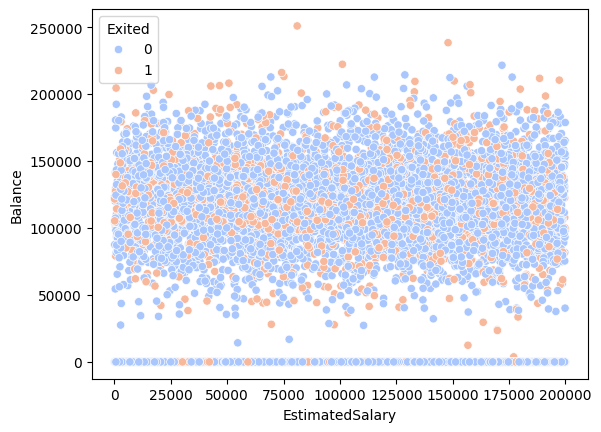

In [117]:
sns.scatterplot(data=df,x=df['EstimatedSalary'],y=df['Balance'],hue=df['Exited'],palette='coolwarm')

lets check if low estimated salary have any impact on the churn rate of the customers

In [86]:
df.groupby(df['EstimatedSalary']<50000)['Exited'].mean()*100

EstimatedSalary
False    20.511462
True     19.934774
Name: Exited, dtype: float64

In [87]:
df.groupby(df['EstimatedSalary']<50000)['Exited'].value_counts()

EstimatedSalary  Exited
False            0         5999
                 1         1548
True             0         1964
                 1          489
Name: count, dtype: int64

estimatedsalary vs exited
1. estimated salay show 19 % churn rate with the customers salaru low than the mean . comparing to the customer with the salay above the mean have have 20 % churn rate . the size of the customer with above mean salry is 3iple the s

In [88]:
df.sample(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,credit_score_class,tenure_class
1308,1309,15662294,Bennett,710,France,Male,33,10,118327.17,2,1,1,192928.82,0,young,good,loyal
6526,6527,15700946,Kolesnikova,574,France,Female,34,7,152992.91,1,1,1,134691.20,0,young,fair,loyal
4180,4181,15569438,Mai,607,Germany,Male,36,10,106702.94,2,0,0,198313.69,0,young,fair,loyal
4528,4529,15624995,McCane,714,Spain,Female,31,6,152926.60,1,1,1,50899.91,0,young,good,loyal


In [89]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64